<a href="https://colab.research.google.com/github/kaifahmad236/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kaifahmad236/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os
from pathlib import Path
import duckdb
import pandas as pd
import numpy as np

OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Working directory:", os.getcwd())
print("Output directory:", OUTPUT_DIR.resolve())

Working directory: /content
Output directory: /content/work/outputs


## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The playbook ranks content items using the validated decision-support signals from the earlier baseline work. Each ranked item receives one reason code and one human-readable action. The ranking is intended to prioritize review effort rather than automatically change or publish content.

The main action used here is `Optimize Title & Meta`, associated with the observed pattern of relatively low CTR combined with a weaker average search position. The score is a prioritization score, not a probability and not a causal estimate of expected improvement.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os
import duckdb
import pandas as pd
import numpy as np
from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError("HF_TOKEN was not found in Colab Secrets.")

con = duckdb.connect()

con.execute(
    f"""
    CREATE OR REPLACE SECRET hf (
        TYPE huggingface,
        TOKEN '{HF_TOKEN}'
    )
    """
)

REL = "hf://datasets/FlyRank/internship-warehouse"

query = f"""
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks,
    AVG(gsc_avg_position) AS avg_position
FROM read_parquet('{REL}/fact_content_daily_performance/**/*.parquet')
GROUP BY client_hash_id, content_hash_id
HAVING SUM(gsc_impressions) > 500
"""

df = con.sql(query).df()

df["ctr"] = np.where(
    df["impressions"] > 0,
    df["clicks"] / df["impressions"],
    0
)

df["score"] = (
    df["impressions"] * 0.5
    + (1 - df["ctr"]) * 1000 * 0.3
    + np.maximum(0, 30 - df["avg_position"]) * 10 * 0.2
)

df["reason_code"] = "LOW_CTR_HIGH_POSITION"
df["action"] = "Optimize Title & Meta"

queue = (
    df[
        [
            "client_hash_id",
            "content_hash_id",
            "impressions",
            "clicks",
            "ctr",
            "avg_position",
            "score",
            "reason_code",
            "action",
        ]
    ]
    .sort_values("score", ascending=False)
    .reset_index(drop=True)
)

queue["rank"] = np.arange(1, len(queue) + 1)

queue = queue[
    [
        "rank",
        "client_hash_id",
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "score",
        "reason_code",
        "action",
    ]
]

print("HF_TOKEN loaded successfully.")
print("Ranked queue shape:", queue.shape)

display(queue.head(20))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

HF_TOKEN loaded successfully.
Ranked queue shape: (129477, 10)


,rank,client_hash_id,content_hash_id,impressions,clicks,ctr,avg_position,score,reason_code,action
0,1,client_e547b89c05043229,content_eadb33b5df496f4a,2902616.0,24747.0,0.008526,2.636037,1.451660e+06,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
1,2,client_73cda7b4e4f265ea,content_e241d6415ac9e534,1829204.0,5714.0,0.003124,4.914556,9.149512e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
2,3,client_73cda7b4e4f265ea,content_cf651123f1085418,1388464.0,2704.0,0.001947,7.369299,6.945767e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
3,4,client_23a62021009f63c4,content_e8a52cf3d5988c07,1285914.0,5495.0,0.004273,11.665600,6.432924e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
4,5,client_08a6a72ff48e62c0,content_e7b5dd4dff461ad2,1265772.0,13210.0,0.010436,6.203495,6.332305e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
5,6,client_73cda7b4e4f265ea,content_b17c1d1cb0a346d6,1245353.0,5997.0,0.004816,5.755486,6.230235e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
6,7,client_fef1a8f436438636,content_0717da99fbd8c274,1222089.0,10160.0,0.008314,11.129908,6.113797e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
7,8,client_73cda7b4e4f265ea,content_471d9cabce329a66,1208380.0,2985.0,0.002470,6.888409,6.045355e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
8,9,client_e547b89c05043229,content_545bb6cc7081ded3,1177698.0,5182.0,0.004400,3.071687,5.892015e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
9,10,client_e547b89c05043229,content_963de14b1f58978f,1135755.0,3068.0,0.002701,4.935717,5.682268e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

This playbook is intended to support human prioritization of content-review work. It ranks content items using measured signals and provides a reason code and suggested action so that reviewers can decide which items to inspect first.

The ranked score is a prioritization score. It is not a probability, forecast, or estimate of expected performance improvement. A high score does not establish that a content item caused its own performance outcome or that the suggested action will improve future performance.

The recommendations are valid only for the data definitions, measurement period, and signals used in this analysis. Changes in the underlying data, reporting window, search environment, or content context may change the usefulness of the ranking.

The queue should therefore be treated as decision-support. A human reviewer should verify the page context and the underlying measurements before taking any action.

In [8]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

print("Intended use and limitations documented.")
print("The ranked queue is for human decision-support and prioritization only.")

Intended use and limitations documented.
The ranked queue is for human decision-support and prioritization only.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Every recommended action requires human review before implementation. The reviewer should verify the observed signals, the page context, search intent, recent content changes, and whether the available measurements are sufficient for the decision.

Before acting, the reviewer should confirm:

1. The content item is still relevant to the intended audience and search intent.
2. The impressions, clicks, CTR, and average position measurements are recent and comparable.
3. No recent content or technical change already explains the observed pattern.
4. The item has sufficient measured activity for the recommendation to be useful.
5. The proposed action is appropriate for the content and its surrounding business context.

The following should not be automated from this playbook: deleting content, publishing rewritten content, changing canonical URLs, creating redirects, making legal or compliance decisions, or making other business-critical changes.

The score and reason code should never override editorial judgment. The safest use of the queue is to prioritize which items a human should review first.

In [9]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

print("Human review requirements documented.")
print("No-go cases identified for decisions that should not be automated.")

Human review requirements documented.
No-go cases identified for decisions that should not be automated.


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

The playbook should be reviewed when the underlying data or observed behavior changes materially. Useful monitoring signals include the distribution of prioritization scores, the number of items entering the queue, the distribution of reason codes and actions, and changes in the measured input features.

A review of the rule or model should be considered when:

- the distribution of important input features changes materially;
- the number or type of recommended actions changes unexpectedly;
- the underlying data definition or reporting window changes;
- important input fields are added, removed, or redefined;
- repeated human review shows that recommendations are frequently unsuitable;
- validation performance of the underlying model falls materially from its previously measured result.

These are review triggers rather than automatic retraining commands. Before retraining, the data definition, feature availability, target definition, and validation design should be checked again.

In [10]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

print("Monitoring and review triggers documented.")
print("Changes in data, feature distributions, recommendations, or validation performance should trigger review.")

Monitoring and review triggers documented.
Changes in data, feature distributions, recommendations, or validation performance should trigger review.


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

The ranked queue generated above is exported to `work/outputs/` so that the research paper can reuse the same decision-support output. Summary files are also created for the action and reason-code distributions.

The queue is treated as a reproducible notebook output rather than a committed dataset. The notebook can regenerate it from the underlying data when it is rerun.

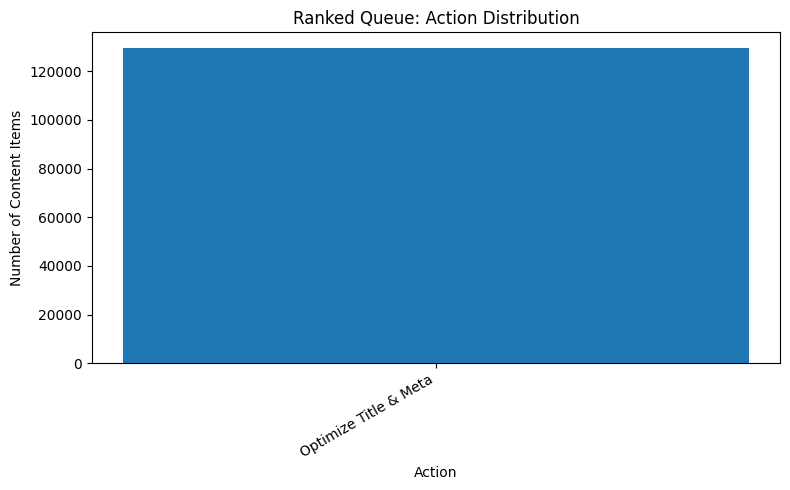

Queue exported to: work/outputs/ml10_ranked_action_queue.csv
Action summary exported to: work/outputs/ml10_action_summary.json
Reason summary exported to: work/outputs/ml10_reason_summary.json
Figure exported to: work/figures/ml10_action_distribution.png

Action summary:


,action,count
0,Optimize Title & Meta,129477



Reason-code summary:


,reason_code,count
0,LOW_CTR_HIGH_POSITION,129477


In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.

from pathlib import Path
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("work/outputs")
FIGURE_DIR = Path("work/figures")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

queue_path = OUTPUT_DIR / "ml10_ranked_action_queue.csv"

queue.to_csv(queue_path, index=False)

action_summary = (
    queue["action"]
    .value_counts()
    .rename_axis("action")
    .reset_index(name="count")
)

reason_summary = (
    queue["reason_code"]
    .value_counts()
    .rename_axis("reason_code")
    .reset_index(name="count")
)

action_summary.to_json(
    OUTPUT_DIR / "ml10_action_summary.json",
    orient="records",
    indent=2
)

reason_summary.to_json(
    OUTPUT_DIR / "ml10_reason_summary.json",
    orient="records",
    indent=2
)

plt.figure(figsize=(8, 5))

plt.bar(
    action_summary["action"],
    action_summary["count"]
)

plt.title("Ranked Queue: Action Distribution")
plt.xlabel("Action")
plt.ylabel("Number of Content Items")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

action_figure = FIGURE_DIR / "ml10_action_distribution.png"

plt.savefig(
    action_figure,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("Queue exported to:", queue_path)
print("Action summary exported to:", OUTPUT_DIR / "ml10_action_summary.json")
print("Reason summary exported to:", OUTPUT_DIR / "ml10_reason_summary.json")
print("Figure exported to:", action_figure)

print("\nAction summary:")
display(action_summary)

print("\nReason-code summary:")
display(reason_summary)

In [7]:
print("Final verification")
print("------------------")

print("Queue rows:", len(queue))
print("Queue columns:", list(queue.columns))
print("CSV exists:", queue_path.exists())
print("Action JSON exists:", (OUTPUT_DIR / "ml10_action_summary.json").exists())
print("Reason JSON exists:", (OUTPUT_DIR / "ml10_reason_summary.json").exists())
print("Figure exists:", action_figure.exists())

print("\nTop 10 ranked actions:")
display(
    queue.head(10)[
        [
            "rank",
            "content_hash_id",
            "score",
            "reason_code",
            "action"
        ]
    ]
)

Final verification
------------------
Queue rows: 129477
Queue columns: ['rank', 'client_hash_id', 'content_hash_id', 'impressions', 'clicks', 'ctr', 'avg_position', 'score', 'reason_code', 'action']
CSV exists: True
Action JSON exists: True
Reason JSON exists: True
Figure exists: True

Top 10 ranked actions:


,rank,content_hash_id,score,reason_code,action
0,1,content_eadb33b5df496f4a,1.451660e+06,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
1,2,content_e241d6415ac9e534,9.149512e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
2,3,content_cf651123f1085418,6.945767e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
3,4,content_e8a52cf3d5988c07,6.432924e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
4,5,content_e7b5dd4dff461ad2,6.332305e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
5,6,content_b17c1d1cb0a346d6,6.230235e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
6,7,content_0717da99fbd8c274,6.113797e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
7,8,content_471d9cabce329a66,6.045355e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
8,9,content_545bb6cc7081ded3,5.892015e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta
9,10,content_963de14b1f58978f,5.682268e+05,LOW_CTR_HIGH_POSITION,Optimize Title & Meta


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.